In [10]:
import numpy as np
import matplotlib.pyplot as plt
from module.clustering.config import CorrfuncConfig, AnalysisConfig
from module.clustering.cosmology import desi_cosmology
from module.clustering.pipeline import compute_monopole

In [6]:
cfg = CorrfuncConfig(
    nthreads=8,       
    mu_max=1.0,
    nmu_bins=10,        
    binfile=np.linspace(20, 150, 20),
    output_savg=False,
    mode="xyz",    
)
acfg = AnalysisConfig(
    zbins={
        "z1": (0.8, 1.1),
        "z2": (1.1, 1.6),
    },
    combine_regions=True,
    regions=("NGC", "SGC"),
    use_jackknife=True,　# Jackknife is supported only for mode="xyz"
    n_jack=20,
)

In [3]:
cosmo = desi_cosmology()

data_path = {
    "NGC": "/data/honke/DESI_clu/ELG_LOPnotqso_NGC_clustering.dat.fits",
    "SGC": "/data/honke/DESI_clu/ELG_LOPnotqso_SGC_clustering.dat.fits",
}

random_path = {
    "NGC": ["/data/honke/DESI_clu/ELG_LOPnotqso_NGC_0_clustering.ran.fits"],
    "SGC": ["/data/honke/DESI_clu/ELG_LOPnotqso_SGC_0_clustering.ran.fits"],
}


In [7]:
results = compute_monopole(
    data_path,
    random_path,
    cosmo,
    cfg,
    acfg,
)

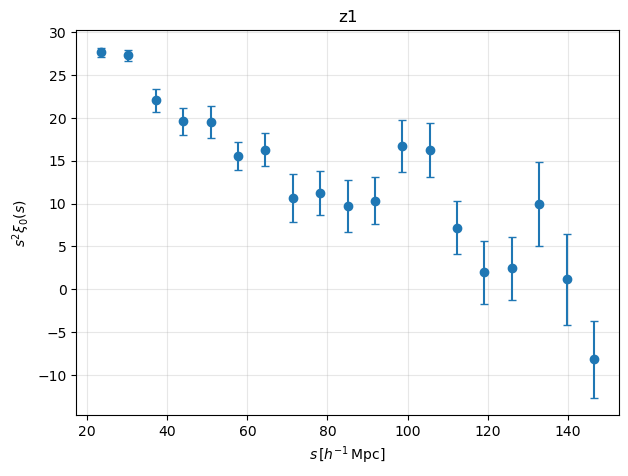

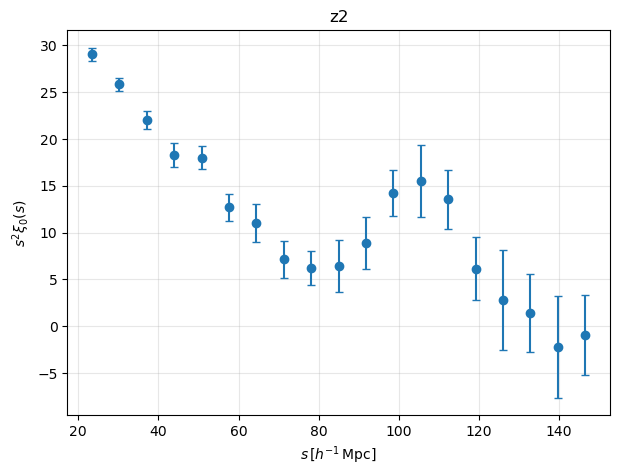

In [9]:
import matplotlib.pyplot as plt

for zlabel, out in results.items():

    plt.figure(figsize=(7, 5))

    if len(out) == 3:
        s, xi0, err = out
        plt.errorbar(
            s,
            s**2 * xi0,
            yerr=s**2 * err,
            fmt="o",
            capsize=3,
        )
    else:
        s, xi0 = out
        plt.plot(
            s,
            s**2 * xi0,
            marker="o",
        )

    plt.title(zlabel)
    plt.xlabel(r"$s\,[h^{-1}\,\mathrm{Mpc}]$")
    plt.ylabel(r"$s^2 \xi_0(s)$")
    plt.grid(alpha=0.3)
    plt.show()